# Análisis de KPIs — ATFM

Consulta el warehouse `data/processed/atfm_warehouse.duckdb` (generado por
`python main.py`) y visualiza los KPIs definidos en `sql/dml/`.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import duckdb
import matplotlib.pyplot as plt

from src.config.settings import WAREHOUSE_DB_PATH, DML_DIR

con = duckdb.connect(str(WAREHOUSE_DB_PATH), read_only=True)
con.execute('SELECT COUNT(*) AS vuelos FROM fact_vuelo').df()

,vuelos
0,96854


## 1. Tráfico por aeropuerto

In [2]:
sql_trafico = (DML_DIR / 'kpi_trafico.sql').read_text(encoding='utf-8')
consulta_aeropuertos, consulta_rutas = [q for q in sql_trafico.split(';') if q.strip()]

top_aeropuertos = con.execute(consulta_aeropuertos).df()
top_aeropuertos.head(10)

,codigo_icao,salidas,llegadas,total_operaciones
0,KORD,1133.0,963.0,2096.0
1,KATL,1036.0,1009.0,2045.0
2,KDEN,864.0,807.0,1671.0
3,KDFW,842.0,676.0,1518.0
4,KMIA,662.0,716.0,1378.0
5,KLAS,666.0,682.0,1348.0
6,KLAX,683.0,633.0,1316.0
7,RJTT,594.0,669.0,1263.0
8,EHAM,609.0,649.0,1258.0
9,EGLL,569.0,606.0,1175.0


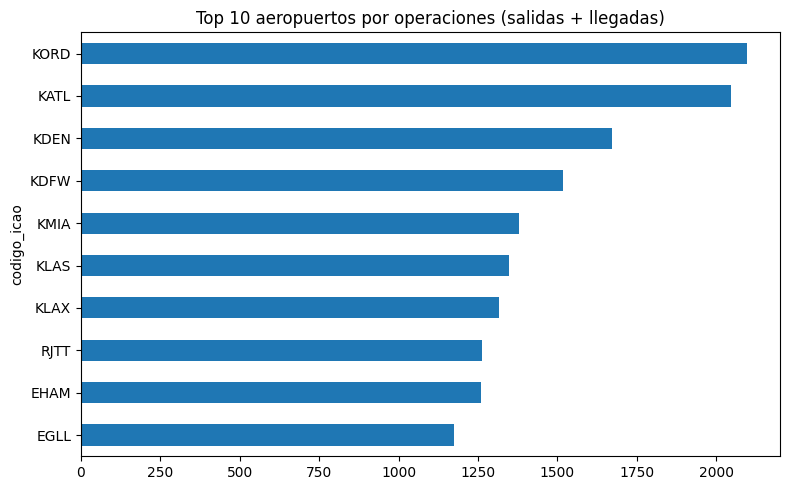

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
top_aeropuertos.head(10).set_index('codigo_icao')['total_operaciones'].plot(kind='barh', ax=ax)
ax.set_title('Top 10 aeropuertos por operaciones (salidas + llegadas)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Rutas más frecuentes

In [4]:
top_rutas = con.execute(consulta_rutas).df()
top_rutas.head(10)

,origen,destino,num_vuelos,duracion_promedio_min,distancia_promedio_km
0,KFFZ,KFFZ,159,78.5,273.4
1,KBJC,KBJC,141,75.0,249.5
2,KMYF,KMYF,94,77.0,232.5
3,KIWA,KIWA,89,70.4,215.2
4,KAPA,KAPA,89,63.9,184.1
5,YSBK,YSBK,82,53.8,143.9
6,YMML,YSSY,79,77.5,834.3
7,YMMB,YMMB,79,52.4,146.0
8,YSSY,YMML,78,103.0,1018.3
9,KSFB,KSFB,76,72.6,227.7


## 2. Congestión y picos de tráfico

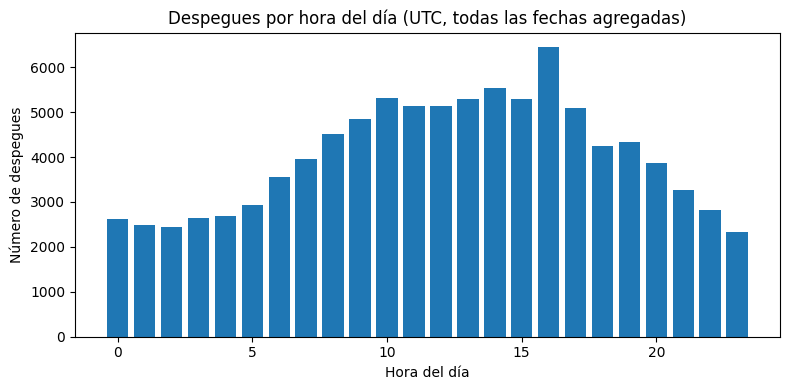

In [5]:
sql_congestion = (DML_DIR / 'kpi_congestion.sql').read_text(encoding='utf-8')
consulta_hora, consulta_pico_aeropuerto, consulta_dia_semana = [q for q in sql_congestion.split(';') if q.strip()]

demanda_por_hora = con.execute(consulta_hora).df()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(demanda_por_hora['hora_del_dia'], demanda_por_hora['num_despegues'])
ax.set_title('Despegues por hora del día (UTC, todas las fechas agregadas)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de despegues')
plt.tight_layout()
plt.show()

In [6]:
picos_aeropuerto_hora = con.execute(consulta_pico_aeropuerto).df()
picos_aeropuerto_hora.head(10)

,aeropuerto,hora_del_dia,num_despegues
0,KORD,10,98
1,KATL,10,96
2,KDEN,13,82
3,KDFW,22,81
4,KORD,11,80
5,KORD,19,79
6,KORD,8,78
7,KORD,15,78
8,KDFW,11,78
9,KORD,14,76


## 3. Capacidad vs. demanda (proxy de saturación)

In [7]:
sql_capacidad = (DML_DIR / 'kpi_capacidad_demanda.sql').read_text(encoding='utf-8')
saturacion = con.execute(sql_capacidad).df()
saturacion.head(15)

,aeropuerto,franja_horaria,demanda,capacidad_estimada,indice_saturacion,saturado
0,KMKT,2026-03-01 17:00:00,8,2.0,4.00,True
1,CZBB,2026-02-28 19:00:00,13,5.0,2.60,True
2,KRFD,2026-03-01 16:00:00,5,2.0,2.50,True
3,UGTB,2026-02-28 21:00:00,6,2.5,2.40,True
4,KNY2,2026-03-01 06:00:00,7,3.0,2.33,True
5,KMIC,2026-03-01 16:00:00,9,3.9,2.31,True
6,98VA,2026-03-01 13:00:00,9,4.0,2.25,True
7,KONT,2026-03-01 09:00:00,11,5.0,2.20,True
8,KBDL,2026-03-01 06:00:00,14,6.4,2.19,True
9,KPDX,2026-03-01 10:00:00,30,14.2,2.11,True


El índice de saturación compara la demanda horaria observada contra el
percentil 90 de la demanda histórica del propio aeropuerto (proxy de
capacidad, ya que el dataset no trae capacidades declaradas). Un valor > 1
indica una franja por encima de lo habitual para ese aeropuerto.

## 4. Puntualidad / retraso relativo por ruta

In [8]:
sql_puntualidad = (DML_DIR / 'kpi_puntualidad.sql').read_text(encoding='utf-8')
retrasos = con.execute(sql_puntualidad).df()
retrasos['clasificacion'].value_counts()

clasificacion
dentro_de_lo_normal        15780
mas_lento_que_lo_usual      3570
mas_rapido_que_lo_usual     2954
Name: count, dtype: int64

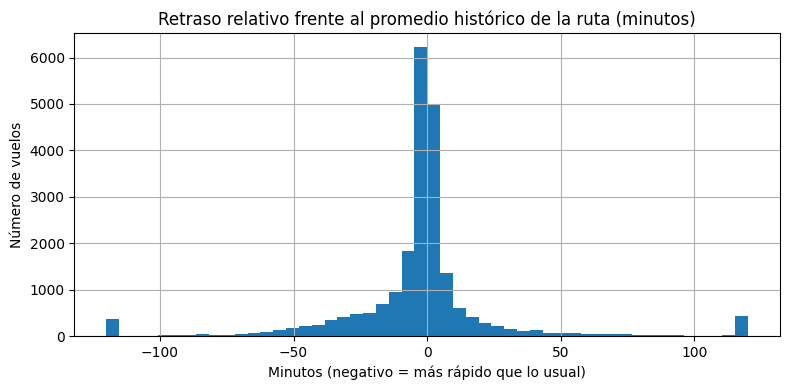

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
retrasos['retraso_relativo_minutos'].clip(-120, 120).hist(bins=50, ax=ax)
ax.set_title('Retraso relativo frente al promedio histórico de la ruta (minutos)')
ax.set_xlabel('Minutos (negativo = más rápido que lo usual)')
ax.set_ylabel('Número de vuelos')
plt.tight_layout()
plt.show()

In [10]:
con.close()